In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget
%matplotlib widget

In [2]:
project_name = "syn"
condition = "repro"
data = "biased_00"
switch_epoch = 0
checkpoint_epoch = 50

n_samples_test = 1000
show_results_fusion = True
fusion_attr_weight = 1.0

experiment_name = get_experiment_name(condition, data, switch_epoch)
cat_names=CAT_NAMES

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/repro_biased_00/checkpoints/save-epoch=50.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/repro_biased_00/checkpoints/save-epoch=50.ckpt


In [3]:
training_params

{'experiment_name': 'repro_biased_00',
 'exclude_colors': True,
 'apply_custom_init': True,
 'config': Config(seed=124, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='/home/lucas/gwsyn/simple_shapes_dataset_biased_00'), training=Training(batch_size=300, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=200000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, log_val_medias_eve

In [4]:
# 1. Paramètres initiaux
noise_params = {'std': 0.05, 'mean': 0.0}
n_iterations = 2

# 2. Préparation du premier échantillon (initialisation)
test_samples = get_data_samples(data_module, n_samples_test, split="test")
# On initialise 'reshape' avec les attributs de départ
current_attr = test_samples[frozenset({'attr', 'v_latents'})]['attr']

# On utilise torch.no_grad() pour éviter l'accumulation du graphe de calcul (fuite mémoire)
with torch.no_grad():
    for i in range(n_iterations):
        # Préparation du dictionnaire pour l'encodage
        samples_dict = {frozenset({'attr', 'v_latents'}): {"attr": current_attr}}
        
        # Encodage
        unimodal_latents = global_workspace.encode_domains(samples_dict)
        gw_latents = global_workspace.encode(unimodal_latents)
        gw_latents_attr = gw_latents[frozenset({'attr', 'v_latents'})]['attr']

        # Ajout du bruit
        noise = torch.randn_like(gw_latents_attr) * noise_params['std'] + noise_params['mean']
        gw_latents_attr_noisy = gw_latents_attr + noise

        # Décodage vers image puis ré-encodage (boucle de reconstruction)
        decoded_image = global_workspace.decode({'attr': gw_latents_attr_noisy})['attr']['v_latents']
        
        # Encodage de l'image décodée
        img_input = {'v_latents': {'v_latents': decoded_image}}
        gw_latent_from_img = global_workspace.encode(img_input)['v_latents']['v_latents']

        # Fusion des deux représentations latentes
        fusion = 0.5 * gw_latents_attr_noisy + 0.5 * gw_latent_from_img

        # Décodage de la fusion vers les attributs
        decoded_attr_from_fusion = global_workspace.decode({'fusion': fusion})['fusion']['attr']

        # Transformation (logits -> probas + split)
        # On extrait ici le résultat pour l'itération suivante
        current_attr = split_softmax_category_attributes(decoded_attr_from_fusion)

In [5]:
def get_n_per_category(source_tensor, current_attr, n_per_cat=5):
    """
    Retourne les n premiers éléments de source_tensor pour chaque catégorie 
    définie dans current_attr.
    
    Args:
        source_tensor: Le tenseur d'où on extrait les données (ex: des images ou latents)
        current_attr: Le tenseur de catégories (one-hot, ex: [Batch, 3])
        n_per_cat: Nombre d'éléments à extraire par catégorie
    """
    # 1. Convertir le one-hot en indices (0, 1, 2)
    labels = current_attr.argmax(dim=-1)
    
    # 2. Trouver les indices pour chaque classe
    indices_list = []
    num_classes = current_attr.shape[-1]
    
    for i in range(num_classes):
        # On récupère les indices où la classe est i
        indices = (labels == i).nonzero(as_tuple=True)[0]
        
        if len(indices) < n_per_cat:
            print(f"Warning: Seulement {len(indices)} éléments trouvés pour la classe {i}")
            indices_list.append(indices)
        else:
            # On ne garde que les n premiers
            indices_list.append(indices[:n_per_cat])
    
    # 3. Concaténer tous les indices sélectionnés
    all_indices = torch.cat(indices_list)
    
    # 4. Retourner le sous-ensemble du tenseur source
    return source_tensor[all_indices]

In [6]:
current_attr

[tensor([[1.0488e-33, 0.0000e+00, 1.0000e+00],
         [7.3711e-34, 9.8091e-45, 1.0000e+00],
         [5.7447e-32, 2.3822e-42, 1.0000e+00],
         ...,
         [1.8078e-32, 5.0867e-43, 1.0000e+00],
         [1.3605e-32, 5.1034e-41, 1.0000e+00],
         [0.0000e+00, 1.0000e+00, 8.7524e-36]], device='cuda:0'),
 tensor([[-0.9297, -1.0000,  1.0000, -1.0000,  0.9948],
         [ 0.2381, -1.0000,  1.0000, -1.0000,  1.0000],
         [ 0.9572, -1.0000,  1.0000, -1.0000,  0.9999],
         ...,
         [ 0.9723, -1.0000,  1.0000, -1.0000,  0.9999],
         [ 0.7139, -1.0000,  1.0000, -1.0000,  0.9998],
         [-1.0000,  1.0000, -1.0000, -1.0000,  1.0000]], device='cuda:0')]

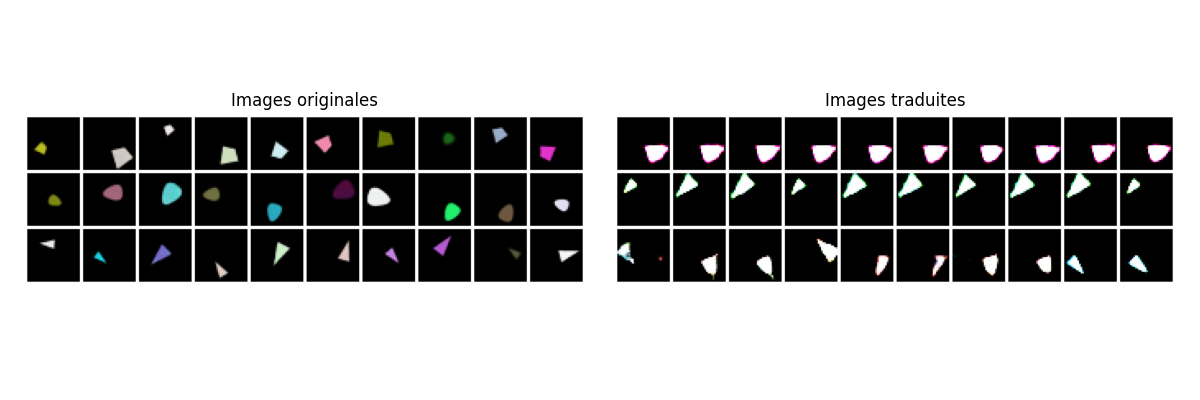

In [7]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_rgb = visual_module.decode_images(decoded_image)
original_images = test_samples[frozenset({'attr', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)

import matplotlib.pyplot as plt


fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, current_attr[0], 10), get_n_per_category(decoded_images_rgb, current_attr[0], 10))
plt.show()



In [8]:
img = decoded_images_rgb[10].permute(1, 2, 0).detach().cpu().numpy()
mask = get_color_mask(img, 1, 1, 254)

get_color_from_image(img, mask)*255

array([129.75739807,  20.13771862,  90.31017199])

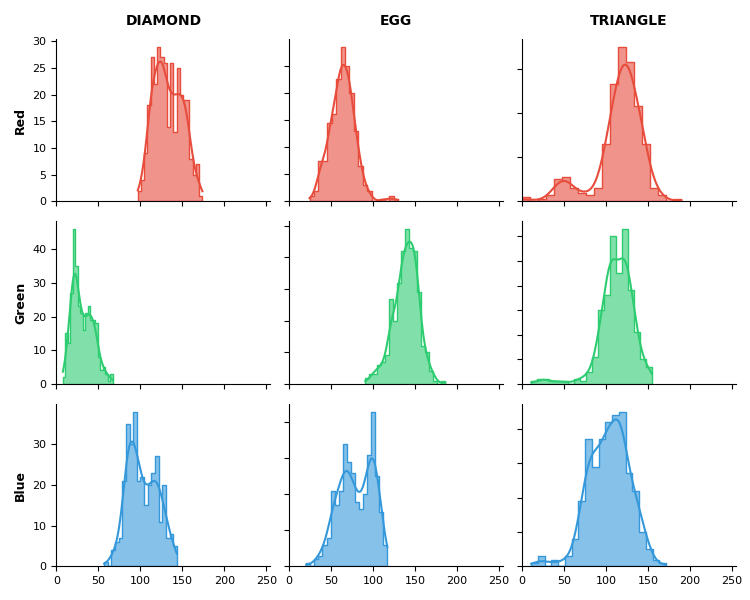

In [9]:
plot_type = "decoded_edge"
n_samples_test = 1000
data_translated = get_data_translated(global_workspace, test_samples, n_samples_test)

colors_np = get_samples_rgb({"train_images": decoded_images_rgb, "images_decoded": decoded_images_rgb}, plot_type)
categories_indices= get_categories_indices(data_translated)

fig = plot_rgb_distribution(colors_np, categories_indices, n_bins=20)
plt.show()


In [10]:
# est ce qu'on peut reconnaitre la catégorie avec seulement la couleur de l'espace latent attribut?
categories_indices_train = get_categories_indices(data_translated, 'train_attr')
categories_indices_decoded = get_categories_indices(data_translated, 'train_attr')

scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)

X = colors_np 
y = categories_indices_train

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")
print("\nDétails par catégorie :")
print(classification_report(y_test, y_pred))

Précision globale (Accuracy) : 99.00%

Détails par catégorie :
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        61
           1       0.99      1.00      0.99        69
           2       1.00      0.97      0.99        70

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

